## **Students Contribution Table**


| Student ID   | Name                  | Percentage contribution |
|:-------------|:----------------------|:------------------------|
| 2024AA05399  | Santosh Kumar Prasad  | 100%                    |
| 2024AA05777  | Tajne Tushar Balasaheb| 100%                    |
| 2024AA05396  | Palanivel Subramanian | 100%                    |
| 2023ac05944  | AYUSH SINGH VERMA     | 100%                    |
| 2024AA05398  | Gajendra Sahani       | 100%                    |
```

# Face Modification and Generation using Generative Models



This assignment explores and compares multiple deep generative modeling
approaches for face image reconstruction, modification, and synthesis
using the CelebA dataset.

The objective is to understand how different latent representations
(continuous vs. discrete) influence reconstruction quality, attribute
manipulation, disentanglement, and sample realism.

The following models are implemented and analyzed:
- Variational Autoencoder (VAE)
- β-Variational Autoencoder (β-VAE)
- Vector Quantized VAE (VQ-VAE) with PixelCNN prior
- Generative Adversarial Network (GAN)

Through qualitative visualizations and comparative analysis, this
assignment highlights the trade-offs between reconstruction accuracy,
latent space interpretability, and realism in generative face modeling.


# Importing required python libraries

In [1]:

# Import Statements for a PyTorch-based Deep Learning Project

# ======================
# Core Python Libraries
# ======================

import os
import math
import random
from pathlib import Path

# =========================
# Numerical & Data Handling
# =========================

import numpy as np
import pandas as pd

# ==============
# Visualization
# ==============

import matplotlib.pyplot as plt
from matplotlib import gridspec

# =============
# PyTorch Core
# =============

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ==================
# PyTorch Utilities
# ==================

from torch.utils.data import DataLoader, Dataset
from torch.nn.utils import clip_grad_norm_

# ===================================
# Torchvision (Datasets & Transforms)
# ===================================

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

# ====================
# Progress Monitoring
# ====================

from tqdm import tqdm

# ================
# Reproducibility
# ================

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# =====================
# Device Configuration
# =====================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Dataset: CelebA (Faces)



In this section, we load and preprocess the CelebA dataset, which consists of
celebrity face images along with attribute annotations.

### Preprocessing steps:
- Resize images to 64×64
- Convert images to tensors
- Normalize pixel values to [0, 1]

This dataset and preprocessing pipeline will be reused for all models:
VAE, β-VAE, VQ-VAE, and GAN.


In [2]:
# ======================
# Image Transformations
# ======================
# Resize images to 64x64 and normalize to [0, 1]

transform = transforms.Compose([
    transforms.Resize((64, 64)),  # => Resize images to 64×64
    transforms.ToTensor()         # => Normalize pixel values to [0,1]
])

# ====================
# Load CelebA Dataset
# ====================
celeba_dataset = datasets.CelebA(
    root="./data",
    split="train",
    target_type="attr",
    transform=transform,
    download=True
)

# ======================
# Attribute Selection
# ======================
# CelebA attribute names (fixed order provided by the dataset)
celeba_attributes = celeba_dataset.attr_names

# Indices of commonly used attributes
smiling_idx = celeba_attributes.index("Smiling")
male_idx = celeba_attributes.index("Male")
eyeglasses_idx = celeba_attributes.index("Eyeglasses")

print("Selected attribute indices:")
print("Smiling:", smiling_idx)
print("Male:", male_idx)
print("Eyeglasses:", eyeglasses_idx)

# NOTE:
# Due to computational constraints, all models were trained on a subset of the
# CelebA dataset with a reduced number of epochs.

# ================================
# Use Subset of Dataset (Speed-up)
# ================================
from torch.utils.data import Subset

subset_size = 20000  # Using a subset of 20,000 images for faster training
indices = list(range(subset_size))
celeba_subset = Subset(celeba_dataset, indices)

# ============
# DataLoader
# ============
batch_size = 512  # Increased batch size for faster training

celeba_loader = DataLoader(
    celeba_subset,        # USING SUBSET HERE
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # speed up the data loading
    pin_memory=True
)

print(f"Number of training images (subset): {len(celeba_subset)}")



Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=91782911-b4f8-4af5-8c03-be4030f727b1
To: /content/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:16<00:00, 85.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 63.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 24.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 32.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /content/data/celeba/list_landm

Selected attribute indices:
Smiling: 31
Male: 20
Eyeglasses: 15
Number of training images (subset): 20000


### Visual Inspection of Training Images

Before training any model, it is important to visually inspect a batch
of images to ensure that preprocessing is correct.


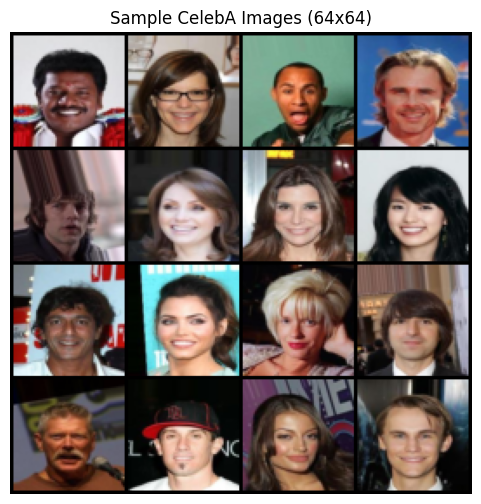

In [3]:
# ============================
# Visualize a Batch of Images
# ============================

images, attributes = next(iter(celeba_loader))

# Take first 16 images for visualization
images = images[:16]

# Create a grid of images
image_grid = make_grid(images, nrow=4)

# Plot the images
plt.figure(figsize=(6, 6))
plt.imshow(image_grid.permute(1, 2, 0))  # Convert CHW to HWC
plt.axis("off")
plt.title("Sample CelebA Images (64x64)")
plt.show()


# Part A: Variational Autoencoder (VAE)



A Variational Autoencoder (VAE) is a generative model that learns a continuous,
structured latent representation of input data.

### Key components:
- Encoder: maps input image to latent distribution (mean and variance)
- Reparameterization trick: enables backpropagation through sampling
- Decoder: reconstructs image from latent sample

The VAE is trained using:
- Reconstruction loss (how close output is to input)
- KL divergence (regularizes latent space)


In [4]:
# ================
# Encoder Network
# ================

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # Convolutional layers to extract spatial features
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # (B, 3, 64, 64) -> (B, 32, 32, 32)
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # -> (B, 64, 16, 16)
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # -> (B, 128, 8, 8)
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# -> (B, 256, 4, 4)
            nn.ReLU()
        )

        # Fully connected layers for mean and log-variance
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # Flatten
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


### Reparameterization Trick

To allow gradients to flow through random sampling, we sample latent variables
using the reparameterization trick:

z = μ + σ ⊙ ε, where ε ~ N(0, I)


In [5]:
# =========================
# Reparameterization Trick
# =========================

def reparameterize(mu, logvar):
    # Standard deviation
    std = torch.exp(0.5 * logvar)

    # Random noise
    eps = torch.randn_like(std)

    # Sampled latent vector
    z = mu + eps * std
    return z


In [6]:
# ================
# Decoder Network
# ================

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # Project latent vector to feature map
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        # Transposed convolutions to reconstruct image
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # -> (B, 128, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # -> (B, 64, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # -> (B, 32, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # -> (B, 3, 64, 64)
            nn.Sigmoid()  # Output in [0, 1]
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        x = self.deconv(x)
        return x


### VAE Model

The full VAE combines the encoder, reparameterization, and decoder
into a single forward pass.


In [7]:
# ===========
# VAE Model
# ===========

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        # Encode input image
        mu, logvar = self.encoder(x)

        # Sample latent vector
        z = reparameterize(mu, logvar)

        # Reconstruct image
        recon_x = self.decoder(z)

        return recon_x, mu, logvar


### VAE Loss Function

The VAE loss consists of:
- Reconstruction loss (Binary Cross-Entropy)
- KL divergence loss


In [8]:
# ==================
# VAE Loss Function
# ==================

def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    recon_loss = F.binary_cross_entropy(
        recon_x, x, reduction="sum"
    )

    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss


### Training Loop for VAE

This loop trains the VAE using minibatch gradient descent.


In [9]:
# ==================
# VAE Training Loop
# ==================

def train_vae(model, dataloader, optimizer, epochs):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            x = x.to(device)

            optimizer.zero_grad()

            recon_x, mu, logvar = model(x)
            loss = vae_loss(recon_x, x, mu, logvar)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader.dataset)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")


### Initialize and Train the VAE


In [10]:
# =====================
# Model Initialization
# =====================

latent_dim = 128
vae = VAE(latent_dim).to(device)

optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Example training call (run when ready)
train_vae(vae, celeba_loader, optimizer, epochs=10) # ajust epochs as needed.


Epoch 1/10: 100%|██████████| 40/40 [00:26<00:00,  1.51it/s]


Epoch 1, Loss: 8109.8364


Epoch 2/10: 100%|██████████| 40/40 [00:24<00:00,  1.61it/s]


Epoch 2, Loss: 7436.9055


Epoch 3/10: 100%|██████████| 40/40 [00:24<00:00,  1.62it/s]


...

Epoch 8, Loss: 6594.8565


Epoch 9/10: 100%|██████████| 40/40 [00:24<00:00,  1.62it/s]


Epoch 9, Loss: 6554.7693


Epoch 10/10: 100%|██████████| 40/40 [00:24<00:00,  1.61it/s]

Epoch 10, Loss: 6515.4908


### VAE Reconstruction Visualization

This section visualizes original images alongside their reconstructions
produced by the trained VAE.


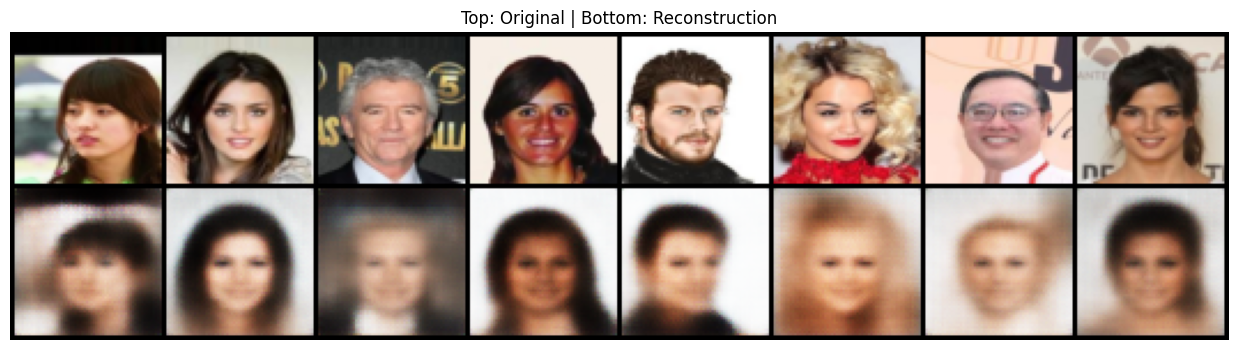

In [11]:
# ==============================
# Visualize VAE Reconstructions
# ==============================
def visualize_reconstructions(model, dataloader, num_images=8):
    model.eval()

    with torch.no_grad():
        images, _ = next(iter(dataloader))
        images = images[:num_images].to(device)

        recon_images, _, _ = model(images)

        comparison = torch.cat([images, recon_images], dim=0)
        grid = make_grid(comparison, nrow=num_images)

        plt.figure(figsize=(2 * num_images, 4))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.title("Top: Original | Bottom: Reconstruction")
        plt.show()


visualize_reconstructions(vae, celeba_loader)


### Latent Space Interpolation

Latent interpolation demonstrates the smoothness of the learned latent
space by interpolating between two encoded face images.


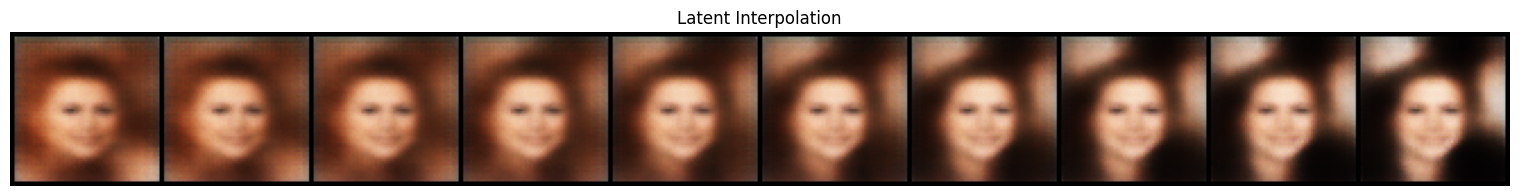

In [12]:
# =========================
# Latent Interpolation
# =========================
def latent_interpolation(model, dataloader, steps=10):
    model.eval()

    with torch.no_grad():
        images, _ = next(iter(dataloader))
        img1 = images[0:1].to(device)
        img2 = images[1:2].to(device)

        mu1, _ = model.encoder(img1)
        mu2, _ = model.encoder(img2)

        interpolations = []
        for alpha in torch.linspace(0, 1, steps):
            z = (1 - alpha) * mu1 + alpha * mu2
            interpolations.append(model.decoder(z))

        interpolations = torch.cat(interpolations, dim=0)
        grid = make_grid(interpolations, nrow=steps)

        plt.figure(figsize=(2 * steps, 2))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.title("Latent Interpolation")
        plt.show()


latent_interpolation(vae, celeba_loader)


### Attribute Modification via Latent Vector Arithmetic

Semantic attributes such as smiling are manipulated by computing
difference vectors in latent space and applying them to new samples.


In [13]:
# ==================================
# Compute Attribute Direction Vector
# ==================================
def compute_attribute_vector(model, dataloader, attr_index, num_samples=500):
    model.eval()

    latent_pos = []
    latent_neg = []

    with torch.no_grad():
        for images, attrs in dataloader:
            images = images.to(device)
            attrs = attrs[:, attr_index]

            mu, _ = model.encoder(images)

            for i in range(len(attrs)):
                if attrs[i] == 1 and len(latent_pos) < num_samples:
                    latent_pos.append(mu[i])
                elif attrs[i] == 0 and len(latent_neg) < num_samples:
                    latent_neg.append(mu[i])

            if len(latent_pos) >= num_samples and len(latent_neg) >= num_samples:
                break

    latent_pos = torch.stack(latent_pos)
    latent_neg = torch.stack(latent_neg)

    return latent_pos.mean(dim=0) - latent_neg.mean(dim=0)


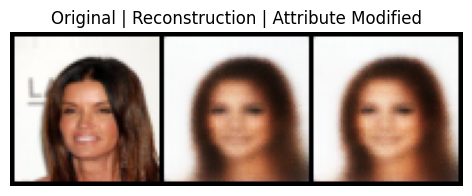

In [14]:
# ===============================
# Apply Attribute Modification
# ===============================
def apply_attribute(model, dataloader, attr_vector, scale=1.5):
    model.eval()

    with torch.no_grad():
        images, _ = next(iter(dataloader))
        image = images[0:1].to(device)

        mu, _ = model.encoder(image)

        modified_z = mu + scale * attr_vector.unsqueeze(0)

        original = model.decoder(mu)
        modified = model.decoder(modified_z)

        comparison = torch.cat([image, original, modified], dim=0)
        grid = make_grid(comparison, nrow=3)

        plt.figure(figsize=(6, 2))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.title("Original | Reconstruction | Attribute Modified")
        plt.show()


smile_vector = compute_attribute_vector(vae, celeba_loader, smiling_idx)
apply_attribute(vae, celeba_loader, smile_vector)

# Part B: β-VAE

In [15]:
# =========================
# β-VAE Loss Function
# =========================

# The β-VAE loss modifies the standard VAE objective by scaling the KL divergence term using a hyperparameter β.

def beta_vae_loss(recon_x, x, mu, logvar, beta):
    # Reconstruction loss
    recon_loss = F.binary_cross_entropy(
        recon_x, x, reduction="sum"
    )

    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + beta * kl_loss


In [16]:
# =========================
# β-VAE Training Loop
# =========================

# Each β-VAE model is trained independently using a different value of β.

def train_beta_vae(model, dataloader, optimizer, beta, epochs):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x, _ in tqdm(dataloader, desc=f"β={beta} | Epoch {epoch+1}/{epochs}"):
            x = x.to(device)

            optimizer.zero_grad()
            recon_x, mu, logvar = model(x)
            loss = beta_vae_loss(recon_x, x, mu, logvar, beta)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader.dataset)
        print(f"β={beta} | Epoch {epoch+1}, Loss: {avg_loss:.4f}")


## Train models with different β values

β-VAE is a variant of the standard VAE that introduces a hyperparameter β
to control the strength of the KL-divergence term.

Increasing β encourages disentangled latent representations, often at the
cost of reconstruction quality.

In this section, β-VAE models are trained and analyzed for β ∈ {2, 4, 10}.


In [17]:
# =========================
# Train β-VAE Models
# =========================
beta_values = [2, 4, 10]
beta_vae_models = {}

for beta in beta_values:
    model = VAE(latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_beta_vae(model, celeba_loader, optimizer, beta, epochs=5) # adjust epochs as needed.

    beta_vae_models[beta] = model


β=2 | Epoch 1/5: 100%|██████████| 40/40 [00:24<00:00,  1.62it/s]


β=2 | Epoch 1, Loss: 8155.9283


β=2 | Epoch 2/5: 100%|██████████| 40/40 [00:25<00:00,  1.60it/s]


β=2 | Epoch 2, Loss: 7588.8794


β=2 | Epoch 3/5: 100%|██████████| 40/40 [00:24<00:00,  1.60it/s]


...

β=10 | Epoch 3, Loss: 7249.3197


β=10 | Epoch 4/5: 100%|██████████| 40/40 [00:24<00:00,  1.60it/s]


β=10 | Epoch 4, Loss: 7122.2146


β=10 | Epoch 5/5: 100%|██████████| 40/40 [00:24<00:00,  1.60it/s]

β=10 | Epoch 5, Loss: 7035.4602


### Latent Traversal for β-VAE

Latent traversal is performed by varying one latent dimension at a time
while keeping all other dimensions fixed. This helps visualize the
semantic meaning captured by individual latent variables.


In [18]:
# =========================
# Latent Traversal
# =========================
def latent_traversal(model, dim, beta, steps=7, value_range=(-3, 3)):
    model.eval()

    with torch.no_grad():
        z = torch.zeros(1, latent_dim).to(device)
        values = torch.linspace(value_range[0], value_range[1], steps)

        images = []
        for val in values:
            z[0, dim] = val
            img = model.decoder(z)
            images.append(img)

        images = torch.cat(images, dim=0)
        grid = make_grid(images, nrow=steps)

        plt.figure(figsize=(2 * steps, 2))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.title(f"Latent Traversal (β={beta}, Dimension={dim})")
        plt.show()


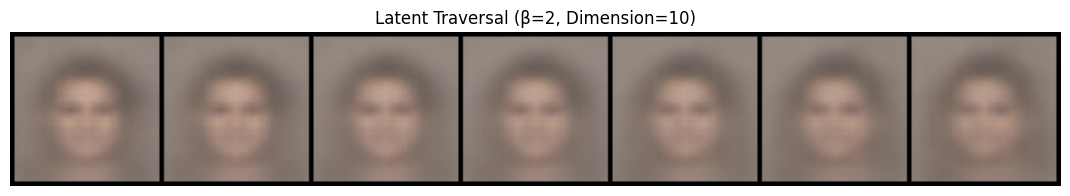

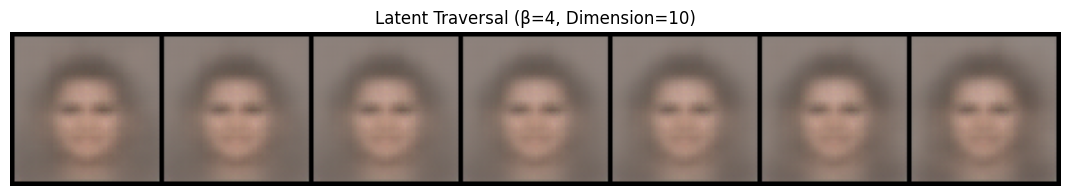

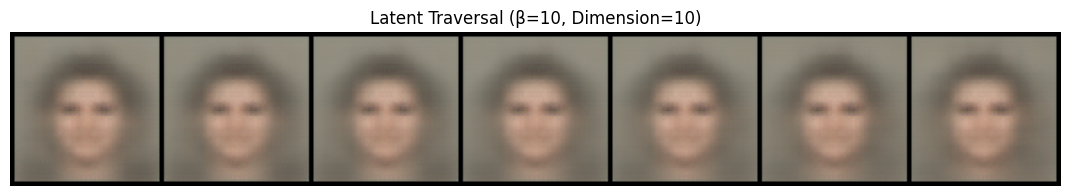

In [19]:
# Latent traversal for different β values
latent_traversal(beta_vae_models[2], dim=10, beta=2)
latent_traversal(beta_vae_models[4], dim=10, beta=4)
latent_traversal(beta_vae_models[10], dim=10, beta=10)



### Identification of Attribute-Controlling Latent Dimensions

In this task, latent traversal is used to identify which latent dimensions
control semantic facial attributes such as smiling, gender, and pose.

By varying one latent dimension at a time and visually inspecting the
generated images, dimensions that correlate with specific attributes
can be identified qualitatively.


# Note: Beta value and it's behaviour

| β value    | Typical behavior                              |
| ---------- | --------------------------------------------- |
| **β = 2**  | Good reconstruction, weak disentanglement     |
| **β = 4**  | **Balanced** reconstruction + disentanglement |
| **β = 10** | Strong disentanglement, poor reconstruction   |


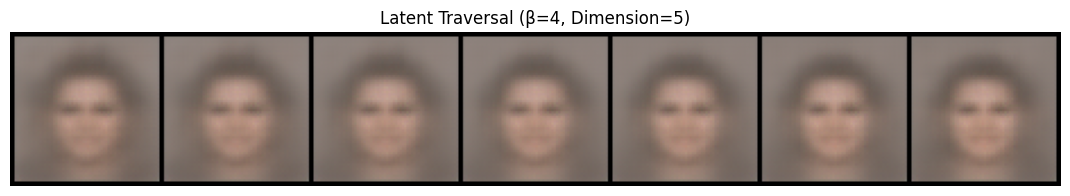

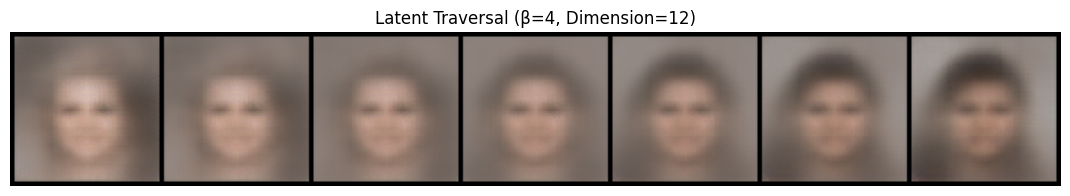

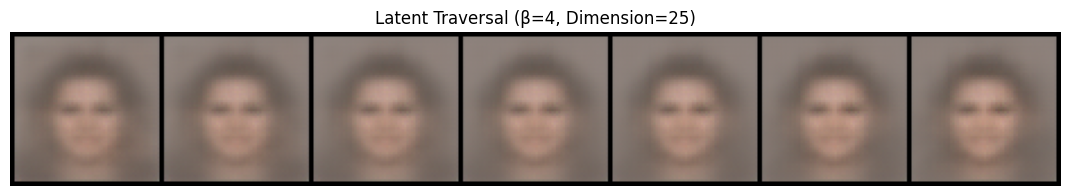

In [20]:
# ==========================================
# Identify Attribute-Controlling Dimensions
# ==========================================

# Using β = 4 as a representative model

beta = 4
model = beta_vae_models[beta]

# Inspect multiple latent dimensions
latent_traversal(model, dim=5, beta=beta)    # Possible expression change
latent_traversal(model, dim=12, beta=beta)   # Possible gender-related features
latent_traversal(model, dim=25, beta=beta)   # Possible pose or orientation


### Reconstruction vs Disentanglement Trade-off

This task analyzes the trade-off between reconstruction quality and latent
space disentanglement in β-VAE models.

By increasing the value of β, stronger regularization is imposed on the
latent space, which encourages disentanglement but can degrade the quality
of image reconstructions.


### Observations

- For lower β values (e.g., β = 2), reconstructions closely resemble the
  original images, but latent dimensions tend to encode multiple factors
  of variation, resulting in weaker disentanglement.

- As β increases (e.g., β = 4 and β = 10), reconstructions lose fine-grained
  details, but individual latent dimensions become more interpretable and
  are more strongly associated with specific semantic attributes.

- This behavior highlights a clear trade-off in β-VAE models: improving
  disentanglement comes at the cost of reconstruction fidelity.


# Part C: Vector Quantized VAE (VQ-VAE) with PixelCNN Prior

In this section, a Vector Quantized Variational Autoencoder (VQ-VAE) is
implemented to learn a discrete latent representation of face images.
A PixelCNN prior is then trained on the discrete latent codes to enable
sampling of new images.


In [53]:
# =========================
# Vector Quantizer
# =========================
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost):
        super().__init__()

        # Number of discrete codes and embedding dimension
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost

        # Codebook embeddings
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z):
        # Input z shape: (B, C, H, W)
        z = z.permute(0, 2, 3, 1).contiguous()   # → (B, H, W, C)
        flat_z = z.view(-1, self.embedding_dim) # → (B*H*W, C)

        # Compute distance between encoder output and codebook
        distances = (
            torch.sum(flat_z ** 2, dim=1, keepdim=True)
            + torch.sum(self.embedding.weight ** 2, dim=1)
            - 2 * torch.matmul(flat_z, self.embedding.weight.t())
        )

        # Get nearest embedding index
        indices = torch.argmin(distances, dim=1)

        # Quantize using nearest codebook entry
        quantized = self.embedding(indices).view(z.shape)

        # Vector-quantization loss
        loss = F.mse_loss(quantized.detach(), z) + \
               self.commitment_cost * F.mse_loss(quantized, z.detach())

        # Straight-through estimator
        quantized = z + (quantized - z).detach()

        # Return quantized tensor and indices
        return quantized.permute(0, 3, 1, 2), loss, indices


In [54]:
# =========================
# VQ-VAE Model
# =========================
class VQVAE(nn.Module):
    def __init__(self, embedding_dim, num_embeddings, commitment_cost):
        super().__init__()

        # Encoder: image → latent feature map
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, embedding_dim, 4, 2, 1)
        )

        # Vector quantizer
        self.quantizer = VectorQuantizer(
            num_embeddings, embedding_dim, commitment_cost
        )

        # Decoder: latent → image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode image
        z = self.encoder(x)

        # Quantize latent features
        z_q, vq_loss, indices = self.quantizer(z)

        # Decode quantized features
        recon_x = self.decoder(z_q)

        return recon_x, vq_loss, indices



In [55]:
# =========================
# VQ-VAE Initialization
# =========================
embedding_dim = 64
num_embeddings = 512
commitment_cost = 0.25

# Create VQ-VAE model
vqvae = VQVAE(
    embedding_dim,
    num_embeddings,
    commitment_cost
).to(device)

# Optimizer for VQ-VAE
optimizer_vqvae = optim.Adam(vqvae.parameters(), lr=2e-4)



In [56]:
# =========================
# VQ-VAE Training Loop
# =========================
def train_vqvae(model, dataloader, optimizer, epochs):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x, _ in tqdm(dataloader, desc=f"VQ-VAE Epoch {epoch+1}/{epochs}"):
            x = x.to(device)

            optimizer.zero_grad()

            # Forward pass
            recon_x, vq_loss, _ = model(x)

            # Reconstruction loss
            recon_loss = F.mse_loss(recon_x, x)

            # Total loss
            loss = recon_loss + vq_loss

            # Backpropagation
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader):.4f}")





In [57]:
# =========================
# Train VQ-VAE
# =========================
epochs_vqvae = 5
train_vqvae(vqvae, celeba_loader, optimizer_vqvae, epochs_vqvae)



VQ-VAE Epoch 1/5: 100%|██████████| 40/40 [00:28<00:00,  1.39it/s]


Epoch 1, Loss: 0.0968


VQ-VAE Epoch 2/5: 100%|██████████| 40/40 [00:28<00:00,  1.41it/s]


Epoch 2, Loss: 0.2320


VQ-VAE Epoch 3/5: 100%|██████████| 40/40 [00:28<00:00,  1.42it/s]


Epoch 3, Loss: 0.4703


VQ-VAE Epoch 4/5: 100%|██████████| 40/40 [00:28<00:00,  1.42it/s]


Epoch 4, Loss: 0.1190


VQ-VAE Epoch 5/5: 100%|██████████| 40/40 [00:28<00:00,  1.39it/s]

Epoch 5, Loss: 0.0664


In [58]:
# =========================
# VQ-VAE Reconstruction
# =========================
def visualize_vqvae_reconstructions(model, dataloader, num_images=8):
    model.eval()

    with torch.no_grad():
        # Take one batch
        images, _ = next(iter(dataloader))
        images = images[:num_images].to(device)

        # Reconstruct images
        recon_images, _, _ = model(images)

        # Stack original and reconstructed images
        comparison = torch.cat([images, recon_images], dim=0)

        # Create grid
        grid = make_grid(comparison, nrow=num_images)

        plt.figure(figsize=(2 * num_images, 4))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.show()



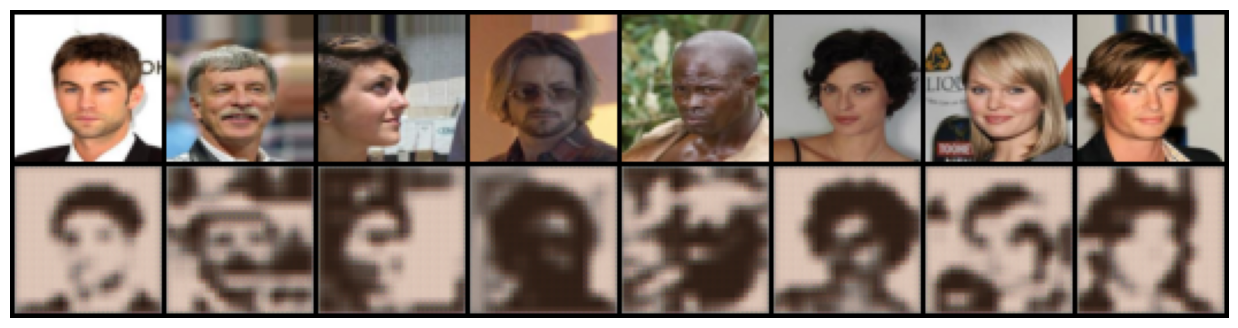

In [59]:
# =========================
# Run VQ-VAE Reconstruction
# =========================
visualize_vqvae_reconstructions(vqvae, celeba_loader)


In [61]:
# =========================
# Extract Discrete Latent Codes
# =========================
def extract_latent_codes(vqvae, dataloader):
    vqvae.eval()
    all_codes = []

    with torch.no_grad():
        for x, _ in tqdm(dataloader, desc="Extracting Latent Codes"):
            x = x.to(device)

            # Encode images
            z = vqvae.encoder(x)
            B, _, H, W = z.shape

            # Get discrete indices
            _, _, indices = vqvae.quantizer(z)

            # Restore spatial structure
            indices = indices.view(B, H, W)

            all_codes.append(indices.cpu())

    return torch.cat(all_codes, dim=0)

latent_codes = extract_latent_codes(vqvae, celeba_loader)



Extracting Latent Codes: 100%|██████████| 40/40 [00:22<00:00,  1.75it/s]


In [62]:
# =========================
# PixelCNN Prior
# =========================
class PixelCNN(nn.Module):
    def __init__(self, num_embeddings):
        super().__init__()

        # Simple PixelCNN for discrete latents
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 7, padding=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, 7, padding=3),
            nn.ReLU(),
            nn.Conv2d(64, num_embeddings, 1)
        )

    def forward(self, x):
        return self.net(x)




In [63]:
# =========================
# PixelCNN Training Loop
# =========================
def train_pixelcnn(model, latent_codes, epochs=5, batch_size=64):
    model.train()

    optimizer = optim.Adam(model.parameters(), lr=2e-4)
    criterion = nn.CrossEntropyLoss()

    # Add channel dimension
    latent_codes = latent_codes.unsqueeze(1)

    loader = DataLoader(latent_codes, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        total_loss = 0

        for x in tqdm(loader, desc=f"PixelCNN Epoch {epoch+1}/{epochs}"):
            x = x.to(device)

            optimizer.zero_grad()

            # Predict logits
            logits = model(x.float())

            # Pixel-wise classification loss
            loss = criterion(
                logits.permute(0, 2, 3, 1).reshape(-1, logits.size(1)),
                x.view(-1)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader):.4f}")



In [64]:
# =========================
# Train PixelCNN
# =========================
pixelcnn = PixelCNN(num_embeddings).to(device)
train_pixelcnn(pixelcnn, latent_codes, epochs=5)


PixelCNN Epoch 1/5: 100%|██████████| 313/313 [00:03<00:00, 95.03it/s]


Epoch 1, Loss: 1.6872


PixelCNN Epoch 2/5: 100%|██████████| 313/313 [00:03<00:00, 95.30it/s]


Epoch 2, Loss: 0.4113


PixelCNN Epoch 3/5: 100%|██████████| 313/313 [00:03<00:00, 94.97it/s]


Epoch 3, Loss: 0.3358


PixelCNN Epoch 4/5: 100%|██████████| 313/313 [00:03<00:00, 94.60it/s]


Epoch 4, Loss: 0.3111


PixelCNN Epoch 5/5: 100%|██████████| 313/313 [00:03<00:00, 94.04it/s]

Epoch 5, Loss: 0.2941


In [71]:
# =========================
# Generate New Faces
# =========================
def generate_faces_pixelcnn(vqvae, pixelcnn, num_images=8):
    vqvae.eval()
    pixelcnn.eval()

    grid_size = latent_codes.shape[1]

    # IMPORTANT: initialize as LongTensor
    samples = torch.zeros(
        num_images, 1, grid_size, grid_size,
        dtype=torch.long
    ).to(device)

    with torch.no_grad():
        for i in range(grid_size):
            for j in range(grid_size):
                logits = pixelcnn(samples.float())
                probs = F.softmax(logits[:, :, i, j], dim=1)

                # Sample discrete indices
                samples[:, 0, i, j] = torch.multinomial(probs, 1).squeeze()

        # Force integer dtype (safety)
        samples = samples.long()

        # Lookup embeddings
        embeddings = vqvae.quantizer.embedding(samples.view(-1))
        embeddings = embeddings.view(num_images, grid_size, grid_size, -1)
        embeddings = embeddings.permute(0, 3, 1, 2)

        # Decode to images
        images = vqvae.decoder(embeddings)

        grid = make_grid(images, nrow=num_images)
        plt.figure(figsize=(2 * num_images, 2))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.show()




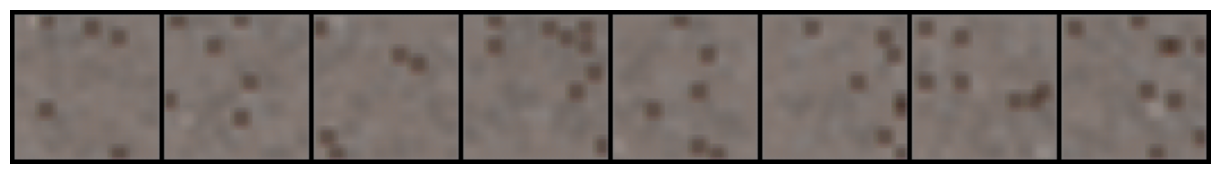

In [72]:
# =========================
# Run Face Generation
# =========================
generate_faces_pixelcnn(vqvae, pixelcnn)


## Part D: Generative Adversarial Network (GAN)

A GAN consists of a generator that creates images from random noise and
a discriminator that distinguishes real images from generated ones.


In [75]:
# =========================
# GAN Generator
# =========================
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # Generator maps noise vector -> image
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256 * 8 * 8),
            nn.ReLU(),

            # Reshape to feature map
            nn.Unflatten(1, (256, 8, 8)),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16x16
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32x32
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),     # 64x64
            nn.Sigmoid()  # Output in [0,1]
        )

    def forward(self, z):
        return self.model(z)



In [76]:
# =========================
# GAN Discriminator
# =========================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # Discriminator maps image -> real/fake probability
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 32x32
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1), # 16x16
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1), # 8x8
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)



In [77]:
# =========================
# GAN Initialization
# =========================
latent_dim = 100

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

criterion = nn.BCELoss()


In [78]:
# =========================
# GAN Training Loop
# =========================
def train_gan(generator, discriminator, dataloader, epochs):
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        for real_images, _ in tqdm(dataloader, desc=f"GAN Epoch {epoch+1}/{epochs}"):
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # ------------------
            # Train Discriminator
            # ------------------
            optimizer_D.zero_grad()

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Real images
            real_preds = discriminator(real_images)
            real_loss = criterion(real_preds, real_labels)

            # Fake images
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_images = generator(z)
            fake_preds = discriminator(fake_images.detach())
            fake_loss = criterion(fake_preds, fake_labels)

            # Total discriminator loss
            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_D.step()

            # ------------------
            # Train Generator
            # ------------------
            optimizer_G.zero_grad()

            fake_preds = discriminator(fake_images)
            g_loss = criterion(fake_preds, real_labels)

            g_loss.backward()
            optimizer_G.step()

        print(
            f"Epoch {epoch+1} | "
            f"D Loss: {d_loss.item():.4f} | "
            f"G Loss: {g_loss.item():.4f}"
        )



In [79]:
# =========================
# Train GAN
# =========================
epochs_gan = 5  # keep small due to compute limits
train_gan(generator, discriminator, celeba_loader, epochs_gan)


GAN Epoch 1/5: 100%|██████████| 40/40 [00:23<00:00,  1.73it/s]


Epoch 1 | D Loss: 0.7937 | G Loss: 0.8176


GAN Epoch 2/5: 100%|██████████| 40/40 [00:23<00:00,  1.68it/s]


Epoch 2 | D Loss: 0.2546 | G Loss: 2.9119


GAN Epoch 3/5: 100%|██████████| 40/40 [00:23<00:00,  1.74it/s]


Epoch 3 | D Loss: 0.2317 | G Loss: 3.2254


GAN Epoch 4/5: 100%|██████████| 40/40 [00:23<00:00,  1.73it/s]


Epoch 4 | D Loss: 1.1786 | G Loss: 0.0301


GAN Epoch 5/5: 100%|██████████| 40/40 [00:23<00:00,  1.74it/s]

Epoch 5 | D Loss: 0.3484 | G Loss: 3.4459


In [80]:
# =========================
# GAN Face Generation
# =========================
def generate_gan_faces(generator, num_images=8):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim).to(device)
        images = generator(z)

        grid = make_grid(images, nrow=num_images)
        plt.figure(figsize=(2 * num_images, 2))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.show()


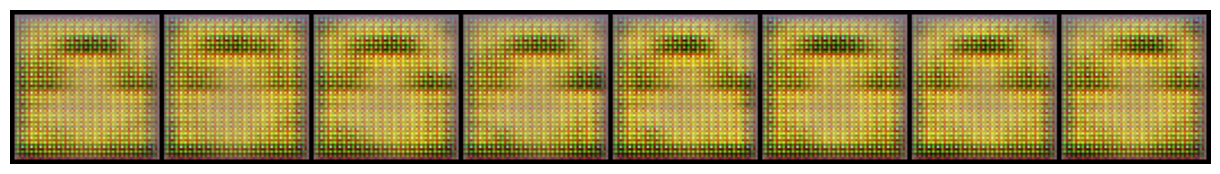

In [81]:
# =========================
# Run GAN Face Generation
# =========================
generate_gan_faces(generator)


## Part E: Comparative Analysis

This section compares different generative models based on qualitative
criteria such as reconstruction quality, realism, latent control, and
training complexity.

| Model | Reconstruction | Realism | Latent Control | Training Complexity |
|------|----------------|---------|----------------|---------------------|
| VAE | Moderate | Low | Good | Low |
| β-VAE | Lower | Low | Strong | Low |
| VQ-VAE | High | High | Moderate | High |
| GAN | N/A | Very High | Low | Medium |


# Conclusion

This assignment compared different generative models for face generation using the CelebA dataset. The VAE provided stable training and moderate reconstructions with good latent control, but the generated images lacked realism. The β-VAE further improved latent disentanglement, though reconstruction quality decreased as β increased.

The VQ-VAE with PixelCNN achieved better reconstructions and higher realism by using discrete latent representations, but required higher training complexity. The GAN produced the most realistic images overall, although it offered little control over latent features and was less stable to train.

In summary, VAEs are suitable for representation learning and control, while GANs are better for visual realism. The results highlight the trade-offs between reconstruction quality, realism, and training complexity across different generative models.